In [3]:
import dynamiqs as dq
import jax.numpy as jnp
import equinox as eqx
from matplotlib import pyplot as plt

from jax import vmap, jit
from cmaes import SepCMA

from scipy.optimize import curve_fit
from scipy.optimize import least_squares

# dq.set_progress_meter(False)

In [ ]:
# Given the initial state, the final time and 2 params (epsilon_d and g_2) in an array find how the system evolves in time
def measure_lifetime(initial_state, tfinal, param):
    na = 15 # Hilbert space dimension
    nb = 5
    a = dq.tensor(dq.destroy(na), dq.eye(nb)) # annihilaiton operator
    b = dq.tensor(dq.eye(na), dq.destroy(nb))

    kappa_b = 10 # MHz
    eps_d = param[0]
    g_2 = param[1] # MHz
    kappa_a = 1 # MHz

    eps_2 = 2 * g_2 * eps_d / kappa_b
    kappa_2 = 4 * jnp.abs(g_2)**2/kappa_b
    alpha_estimate = jnp.sqrt(2/kappa_2 * (eps_2 - kappa_a/4))

    # Removed the print statement to allow jax.vmap and jax.jit to trace the function properly.
    # print(f"Estimated cat size: {alpha_estimate:.2f}")

    H = jnp.conj(g_2) * a @ a @ b.dag() + g_2 * a.dag() @ a.dag() @ b - eps_d * b.dag() - jnp.conj(eps_d) * b

    loss_b = jnp.sqrt(kappa_b) * b
    loss_a = jnp.sqrt(kappa_a) * a

    tsave = jnp.linspace(0, tfinal, 100)

    g_state = dq.coherent(na, alpha_estimate)
    e_state = dq.coherent(na, -alpha_estimate)

    basis = {
        "+z": g_state,
        "-z": e_state,
        "+x": (g_state + e_state) / jnp.sqrt(2),
        "-x": (g_state - e_state) / jnp.sqrt(2),
        "+y": (g_state + 1j*e_state) / jnp.sqrt(2),
        "-y": (g_state - 1j*e_state) / jnp.sqrt(2),
    }

    sx = (1j * jnp.pi * a.dag() @ a).expm()

    # This construction of sigmaz will not work without a good estimate of alpha, which is hard to come by in experiment.
    sz = basis["+z"] @ basis["+z"].dag() - basis["-z"] @ basis["-z"].dag()
    sz = dq.tensor(sz, dq.eye(nb))

    psi0 = dq.tensor(basis[initial_state], dq.fock(nb,0)) # initial state

    res = dq.mesolve(
        H,
        [loss_b, loss_a],
        psi0,
        tsave,
        options=dq.Options(progress_meter=False),
        exp_ops=[sx, sz]
    )

    return res

In [ ]:
import optimistix as optx

#Special fit fuctions that work with jit and vmap

# model: y = A * exp(-t/tau) + C
def model(p, t):
    A, tau, C = p
    return A * jnp.exp(-t/tau) + C

def residuals(p, x, y):
    return model(p, x) - y

# Scipy CPU version
def robust_exp_fit(x, y):
    A0 = y.max() - y.min()
    C0 = y.min()
    tau0 = (x.max() - x.min())
    p0 = [A0, tau0, C0]

    res = least_squares(
        residuals,
        p0,
        args=(x, y),
        bounds=([0, 0, -jnp.inf], [jnp.inf, jnp.inf, jnp.inf]),
        loss="soft_l1",
        f_scale=0.1
    )

    A, tau, C = res.x
    y_fit = model(res.x, x)

    return {
        "popt": res.x,
        "y_fit": y_fit,
    }

# -------------------------------------------------------------------
# JAX-Compatible version using Optimistix
# -------------------------------------------------------------------
def jax_residuals(p, args):
    x, y = args
    return model(p, x) - y

def jax_robust_exp_fit(x, y):
    # Smart initialization (must be JAX arrays)
    A0 = jnp.max(y) - jnp.min(y)
    C0 = jnp.min(y)
    tau0 = (jnp.max(x) - jnp.min(x))
    p0 = jnp.array([A0, tau0, C0])

    # Define the Levenberg-Marquardt solver
    solver = optx.LevenbergMarquardt(rtol=1e-4, atol=1e-4)

    # Solve the least squares problem
    sol = optx.least_squares(
        fn=jax_residuals,
        solver=solver,
        y0=p0,
        args=(x, y),
        max_steps=1000
    )

    # Return the fitted parameters and the generated curve
    y_fit = model(sol.value, x)
    return sol.value, y_fit


In [ ]:
# Find the reward/loss function for a given set of epsilon_d and g_2

@eqx.filter_jit
def cat_loss_func(x):
    na = 15
    nb = 5
    a = dq.tensor(dq.destroy(na), dq.eye(nb)) # annihilaiton operator
    b = dq.tensor(dq.eye(na), dq.destroy(nb))

    kappa_b = 10 # MHz
    eps_d = x[0]
    g_2 = x[1] # MHz
    kappa_a = 1 # MHz

    eps_2 = 2 * g_2 * eps_d / kappa_b
    kappa_2 = 4 * jnp.abs(g_2)**2/kappa_b

    # Fix: Prevent NaN by ensuring the argument to sqrt is non-negative
    inner_val = 2/kappa_2 * (eps_2 - kappa_a/4)
    alpha_estimate = jnp.sqrt(jnp.maximum(0.0, inner_val))

    H = jnp.conj(g_2) * a @ a @ b.dag() + g_2 * a.dag() @ a.dag() @ b - eps_d * b.dag() - jnp.conj(eps_d) * b

    loss_b = jnp.sqrt(kappa_b) * b
    loss_a = jnp.sqrt(kappa_a) * a


    tz = 100.0
    tx = 20.0

    tsave_z = jnp.linspace(0.0, tz, 100)
    tsave_x = jnp.linspace(0.0, tx, 100)

    g_state = dq.coherent(na, alpha_estimate)
    e_state = dq.coherent(na, -alpha_estimate)

    xp = g_state + e_state
    xp = xp / jnp.sqrt((xp.dag() @ xp).real)

    sx = (1j * jnp.pi * a.dag() @ a).expm()
    sz = g_state @ g_state.dag() - e_state @ e_state.dag()
    sz = dq.tensor(sz, dq.eye(nb))

    psi0z = dq.tensor(g_state, dq.fock(nb, 0))
    rho0z = psi0z @ psi0z.dag()
    rho0z = 0.5 * (rho0z + rho0z.dag())

    psi0x = dq.tensor(xp, dq.fock(nb, 0))
    rho0x = psi0x @ psi0x.dag()
    rho0x = 0.5 * (rho0x + rho0x.dag())

    resz = dq.mesolve(
        H,
        [loss_b, loss_a],
        rho0z,
        tsave_z,
        options=dq.Options(progress_meter=False),
        exp_ops=[sx, sz],
    )

    resx = dq.mesolve(
        H,
        [loss_b, loss_a],
        rho0x,
        tsave_x,
        options=dq.Options(progress_meter=False),
        exp_ops=[sx, sz],
    )

    poptx, _ = jax_robust_exp_fit(resx.tsave, resx.expects[0,:].real)
    T_x = poptx[1]

    poptz, _ = jax_robust_exp_fit(resz.tsave, resz.expects[1,:].real)
    T_z = poptz[1]

    bias = 100

    log_bias_error = (jnp.log(T_z/T_x)-jnp.log(bias))**2
    lifetime_bonus = -0.5*jnp.log(T_z +1.0) - .5 * jnp.log(T_x + 1.0)
    return log_bias_error + lifetime_bonus
# NOTE: By applying \texttt{jit} and \texttt{vmap} to the loss function, we can evaluate a JIT-compiled, batched version of the loss efficiently.
batched_cat_loss_func = eqx.filter_jit(vmap(cat_loss_func))

In [11]:
# NOTE: hyperparameters for the optimization

# BATCH_SIZE = 12
# N_EPOCHS = 80

BATCH_SIZE = 12
N_EPOCHS = 25


# ----------------------------------------
# CMA-ES setup
# ----------------------------------------

mean0 = jnp.array([1, 4])     # start near optimum
sigma0 = 0.4                     # exploration scale

optimizer = SepCMA(
    mean=mean0,
    sigma=sigma0,
    bounds=jnp.array([
        [.5, 20.0],    # esp_d bounds
        [.1, 10.0],   # g_2 bounds
    ]),
    population_size=BATCH_SIZE,
    seed=0,
)

# ----------------------------------------
# Logging
# ----------------------------------------
mean_history = []
reward_history = []
reward_std_history = []

# ----------------------------------------
# Training loop
# ----------------------------------------
for epoch in range(N_EPOCHS):
    solutions = []

    # Sample population
    xs = []
    for _ in range(optimizer.population_size):
        xs.append(optimizer.ask())

    xs = jnp.array(xs)
    rewards = batched_cat_loss_func(xs)

    # Format solutions
    solutions = []
    for j in range(len(xs)):
        # Fix: ensure the reward is a real float
        val = float(jnp.real(rewards[j]))
        solutions.append((xs[j], val))

    optimizer.tell(solutions)

    # Log
    mean_history.append(optimizer.mean.copy())
    reward_history.append(float(jnp.mean(jnp.real(rewards))))
    reward_std_history.append(float(jnp.std(jnp.real(rewards))))

    # if epoch % 10 == 0:
    print(f"Epoch {epoch:3d} | mean={optimizer.mean} | avg reward={float(jnp.mean(jnp.real(rewards))):.4f}")


/usr/local/lib/python3.12/dist-packages/equinox/_module/_prebuilt.py:34: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


Epoch   0 | mean=[1.7475712 3.6779435] | avg reward=13.9636
Epoch   1 | mean=[1.9455664 3.536323 ] | avg reward=6.3189
Epoch   2 | mean=[2.214705 2.01184 ] | avg reward=6.2864
Epoch   3 | mean=[5.353179  3.4599888] | avg reward=3.1202
Epoch   4 | mean=[5.8035316 3.7628236] | avg reward=3.1263
Epoch   5 | mean=[7.111889  3.8672945] | avg reward=6.3809
Epoch   6 | mean=[8.568566  4.5320106] | avg reward=3.2499
Epoch   7 | mean=[6.91483   4.5393195] | avg reward=-0.1994
Epoch   8 | mean=[6.840026  4.3551974] | avg reward=-1.1983
Epoch   9 | mean=[6.704659 4.512252] | avg reward=-0.8250
Epoch  10 | mean=[6.8427176 4.5505323] | avg reward=-1.7162
Epoch  11 | mean=[6.7391253 4.460568 ] | avg reward=-1.9455
Epoch  12 | mean=[6.6951365 4.3821964] | avg reward=-1.9560
Epoch  13 | mean=[6.7136884 4.3900948] | avg reward=-0.3560
Epoch  14 | mean=[6.789484 4.434669] | avg reward=-1.9980
Epoch  15 | mean=[6.859014  4.4975038] | avg reward=-1.9942
Epoch  16 | mean=[6.881201 4.519924] | avg reward=-1

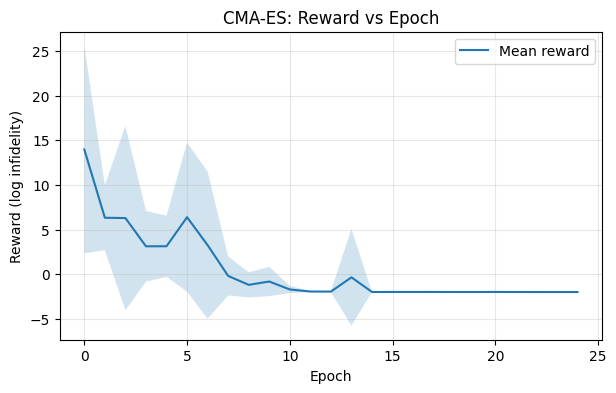

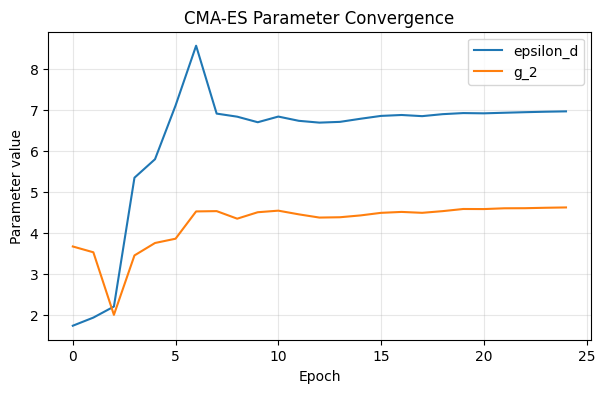

In [12]:
mean_history = jnp.array(mean_history)
reward_history = jnp.array(reward_history)
reward_std_history = jnp.array(reward_std_history)


# ----------------------------------------
# Plot 1: Reward vs epoch
# ----------------------------------------
epochs = jnp.arange(N_EPOCHS)

plt.figure(figsize=(7, 4))
plt.plot(epochs, reward_history, label="Mean reward")
plt.fill_between(
    epochs,
    reward_history - reward_std_history,
    reward_history + reward_std_history,
    alpha=0.2,
)
plt.xlabel("Epoch")
plt.ylabel("Reward (log infidelity)")
plt.title("CMA-ES: Reward vs Epoch")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# ----------------------------------------
# Plot 2: Parameters vs epoch
# ----------------------------------------
plt.figure(figsize=(7, 4))

plt.plot(epochs, mean_history[:, 0], label="epsilon_d")
plt.plot(epochs, mean_history[:, 1], label="g_2")

plt.xlabel("Epoch")
plt.ylabel("Parameter value")
plt.title("CMA-ES Parameter Convergence")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/usr/local/lib/python3.12/dist-packages/equinox/_module/_prebuilt.py:34: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


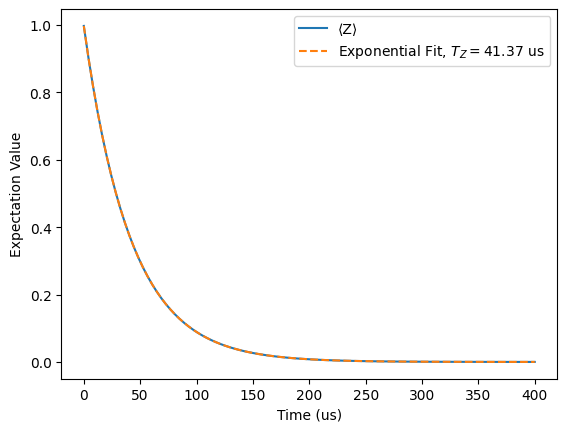

In [13]:
res = measure_lifetime("+z", 400, optimizer.mean)
szt = res.expects[1,:].real
ts = res.tsave

y = szt
x = ts
fit = robust_exp_fit(x, y)
y_fit = fit["y_fit"]
Tz = fit["popt"][1]

plt.plot(ts, szt, label="⟨Z⟩")
plt.plot(ts, y_fit, label="Exponential Fit, $T_Z = $" + "{:.2f}".format(Tz) + " us", linestyle="--")
plt.xlabel("Time (us)")
plt.ylabel("Expectation Value")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/equinox/_module/_prebuilt.py:34: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


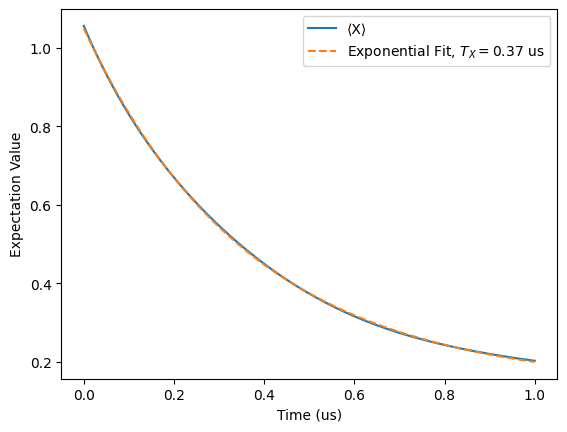

In [14]:
res = measure_lifetime("+x",1.0, optimizer.mean)
sxt = res.expects[0,:].real
ts = res.tsave

y = sxt
x = ts
fit = robust_exp_fit(x, y)
y_fit = fit["y_fit"]
popt = fit["popt"]
Tx = fit["popt"][1]

plt.plot(ts, sxt, label="⟨X⟩")
plt.plot(ts, y_fit, label="Exponential Fit, $T_X = $" + "{:.2f}".format(Tx) + " us", linestyle="--")
plt.xlabel("Time (us)")
plt.ylabel("Expectation Value")
plt.legend()
plt.show()

In [ ]:
# Check ratio value
Tz/Tx

np.float64(111.78456268927827)

Estimated cat size: 1.23


|██████████| 100.0% ◆ elapsed 4.15s ◆ remaining 0.00ms
100%|██████████| 50/50 [00:05<00:00,  9.95it/s]


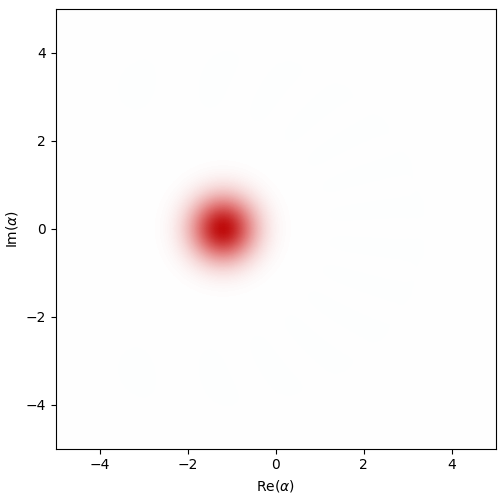

In [ ]:
# Plot the sytem with the found params starting in |-z>
na = 15 # Hilbert space dimension
nb = 5
a = dq.tensor(dq.destroy(na), dq.eye(nb)) # annihilaiton operator
b = dq.tensor(dq.eye(na), dq.destroy(nb))

kappa_b = 10 # MHz
eps_d = optimizer.mean[0]
g_2 = optimizer.mean[1] # MHz
kappa_a = 0 # MHz

eps_2 = 2 * g_2 * eps_d / kappa_b
kappa_2 = 4 * jnp.abs(g_2)**2/kappa_b
alpha_estimate = jnp.sqrt(2/kappa_2 * (eps_2 - kappa_a/4))

print(f"Estimated cat size: {alpha_estimate:.2f}")

H = jnp.conj(g_2) * a @ a @ b.dag() + g_2 * a.dag() @ a.dag() @ b - eps_d * b.dag() - jnp.conj(eps_d) * b

loss_b = jnp.sqrt(kappa_b) * b
loss_a = jnp.sqrt(kappa_a) * a

tsave = jnp.linspace(0, 100, 100)

g_state = dq.coherent(na, alpha_estimate)
e_state = dq.coherent(na, -alpha_estimate)


psi0 = dq.tensor(e_state, dq.fock(nb,0)) # initial state

res = dq.mesolve(H, [loss_b, loss_a], psi0, tsave)
dq.plot.wigner_gif(dq.ptrace(res.states, 0))

Estimated cat size: 1.23


|██████████| 100.0% ◆ elapsed 3.77s ◆ remaining 0.00ms
100%|██████████| 50/50 [00:04<00:00, 10.12it/s]


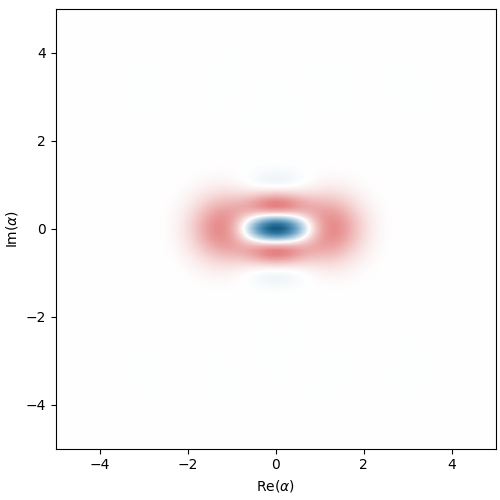

In [ ]:
# Plot the sytem with the found params starting in |-x>
na = 15 # Hilbert space dimension
nb = 5
a = dq.tensor(dq.destroy(na), dq.eye(nb)) # annihilaiton operator
b = dq.tensor(dq.eye(na), dq.destroy(nb))

kappa_b = 10 # MHz
eps_d = optimizer.mean[0]
g_2 = optimizer.mean[1] # MHz
kappa_a = 0 # MHz

eps_2 = 2 * g_2 * eps_d / kappa_b
kappa_2 = 4 * jnp.abs(g_2)**2/kappa_b
alpha_estimate = jnp.sqrt(2/kappa_2 * (eps_2 - kappa_a/4))

print(f"Estimated cat size: {alpha_estimate:.2f}")

H = jnp.conj(g_2) * a @ a @ b.dag() + g_2 * a.dag() @ a.dag() @ b - eps_d * b.dag() - jnp.conj(eps_d) * b

loss_b = jnp.sqrt(kappa_b) * b
loss_a = jnp.sqrt(kappa_a) * a

tsave = jnp.linspace(0, 100, 100)

g_state = dq.coherent(na, alpha_estimate)
e_state = dq.coherent(na, -alpha_estimate)


psi0 = dq.tensor((g_state - e_state) / jnp.sqrt(2), dq.fock(nb,0)) # initial state

res = dq.mesolve(H, [loss_b, loss_a], psi0, tsave)
dq.plot.wigner_gif(dq.ptrace(res.states, 0))

Estimated cat size: 1.23


|██████████| 100.0% ◆ elapsed 132.61ms ◆ remaining 0.00ms
100%|██████████| 50/50 [00:04<00:00, 11.41it/s]


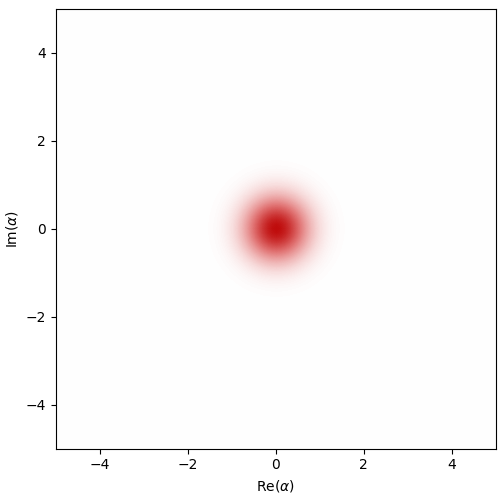

In [ ]:
# Plot the sytem with the found params starting in |0>
na = 15 # Hilbert space dimension
nb = 5
a = dq.tensor(dq.destroy(na), dq.eye(nb)) # annihilaiton operator
b = dq.tensor(dq.eye(na), dq.destroy(nb))

kappa_b = 10 # MHz
eps_d = optimizer.mean[0]
g_2 = optimizer.mean[1] # MHz
kappa_a = 0 # MHz

eps_2 = 2 * g_2 * eps_d / kappa_b
kappa_2 = 4 * jnp.abs(g_2)**2/kappa_b
alpha_estimate = jnp.sqrt(2/kappa_2 * (eps_2 - kappa_a/4))

print(f"Estimated cat size: {alpha_estimate:.2f}")

H = jnp.conj(g_2) * a @ a @ b.dag() + g_2 * a.dag() @ a.dag() @ b - eps_d * b.dag() - jnp.conj(eps_d) * b

loss_b = jnp.sqrt(kappa_b) * b
loss_a = jnp.sqrt(kappa_a) * a

tsave = jnp.linspace(0, 3, 100)

psi0 = dq.tensor(dq.fock(na, 0), dq.fock(nb,0)) # initial state

res = dq.mesolve(H, [loss_b, loss_a], psi0, tsave)
dq.plot.wigner_gif(dq.ptrace(res.states, 0))